# Problem 3 — Fashion MNIST Classifier with PyTorch (Single-Prompt Rebuild)

**CSCI E-89** — This notebook redoes Problems 1 and 2 from scratch in a new Claude Code session:
it builds the complete Fashion MNIST MLP pipeline based on the Chapter 10 template
(*Building Neural Networks with PyTorch*), **plots the training accuracy**, and wraps
everything in one self-contained, executable notebook.

Each code cell is one generated script, labeled **Script NN — `filename.py`**, in the order to run it.

| Cell | Script | Purpose |
|---|---|---|
| 1 | `01_setup.py` | Imports, version checks, device, plot style, hyperparameters |
| 2 | `02_load_data.py` | Download Fashion MNIST, train/valid/test split, DataLoaders |
| 3 | `03_explore_data.py` | Show sample images with class names |
| 4 | `04_build_model.py` | MLP classifier, loss, optimizer, accuracy metric |
| 5 | `05_train_utils.py` | `evaluate()` and `train()` that record accuracy history |
| 6 | `06_train_model.py` | Train the model |
| 7 | `07_plot_training_accuracy.py` | **Plot the training accuracy** (per epoch and per batch) |
| 8 | `08_evaluate_and_predict.py` | Test accuracy and predictions on new images |
| 9 | `09_save_model.py` | Save and reload the model, verify identical predictions |
| 10 | `10_self_test.py` | Automated checks that the whole notebook ran correctly |

To run it: **Kernel → Restart & Run All**. Set `QUICK_RUN = True` in Script 01 for a fast 2-epoch test run.

## Script 01 — `01_setup.py`: setup, imports and configuration

In [1]:
# ===== Script 01 — 01_setup.py =====
import sys
assert sys.version_info >= (3, 10)

from packaging.version import Version
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch
import torch.nn as nn
import torchmetrics
import torchvision

assert Version(sklearn.__version__) >= Version("1.6.1")
assert Version(torch.__version__) >= Version("2.6.0")

IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    %pip install -q torchmetrics

# Use the fastest available device
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Default font sizes to make the figures prettier (as in the template)
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Hyperparameters
QUICK_RUN = False            # True -> 2 epochs, for a fast test
n_epochs = 2 if QUICK_RUN else 20
batch_size = 32
learning_rate = 0.1
n_hidden1, n_hidden2 = 300, 100

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__} | "
      f"TorchVision {torchvision.__version__} | device: {device} | epochs: {n_epochs}")

Python 3.11.15 | PyTorch 2.14.0+cu130 | TorchVision 0.29.0+cu130 | device: cpu | epochs: 20


## Script 02 — `02_load_data.py`: load Fashion MNIST and build the DataLoaders

In [2]:
# ===== Script 02 — 02_load_data.py =====
import contextlib, io
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

# Silence the download progress bar so it doesn't flood the notebook
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    train_and_valid_data = torchvision.datasets.FashionMNIST(
        root="datasets", train=True, download=True, transform=toTensor)
    test_data = torchvision.datasets.FashionMNIST(
        root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

class_names = train_and_valid_data.classes
print(f"train: {len(train_data):,} | valid: {len(valid_data):,} | test: {len(test_data):,}")
print("classes:", class_names)

train: 55,000 | valid: 5,000 | test: 10,000
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Script 03 — `03_explore_data.py`: look at some training images

image tensor shape: (1, 28, 28) | dtype: torch.float32 | pixel range: (0.0, 1.0)


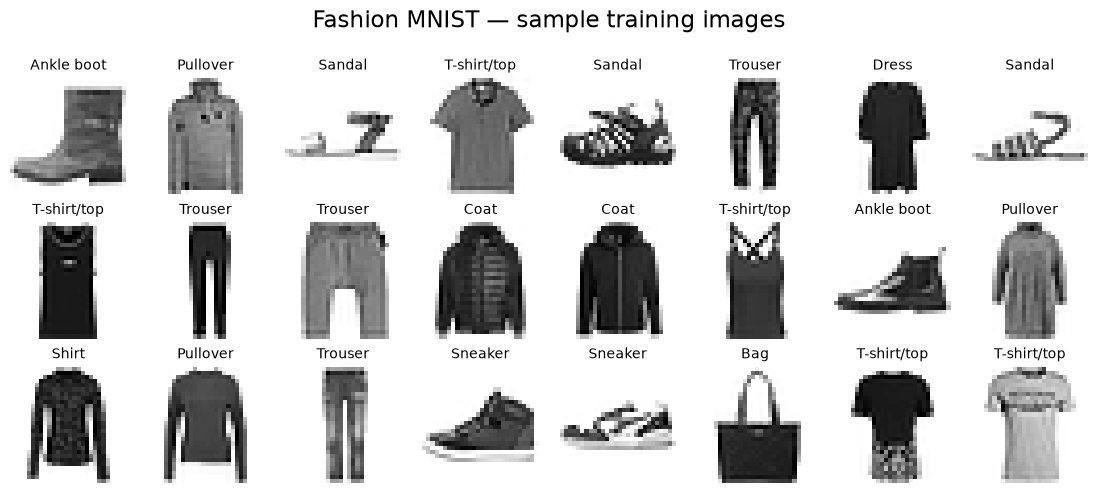

In [3]:
# ===== Script 03 — 03_explore_data.py =====
X_sample, y_sample = train_data[0]
print("image tensor shape:", tuple(X_sample.shape), "| dtype:", X_sample.dtype,
      "| pixel range:", (X_sample.min().item(), X_sample.max().item()))

n_rows, n_cols = 3, 8
plt.figure(figsize=(n_cols * 1.4, n_rows * 1.7))
for index in range(n_rows * n_cols):
    image, label = train_data[index]
    plt.subplot(n_rows, n_cols, index + 1)
    plt.imshow(image.squeeze(), cmap="binary")
    plt.axis("off")
    plt.title(class_names[label], fontsize=10)
plt.suptitle("Fashion MNIST — sample training images")
plt.tight_layout()
plt.show()

## Script 04 — `04_build_model.py`: build the MLP classifier

In [4]:
# ===== Script 04 — 04_build_model.py =====
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden1,
                        n_hidden2=n_hidden2, n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

print(model)
print(f"trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
trainable parameters: 266,610


## Script 05 — `05_train_utils.py`: evaluation and training functions that record accuracy

In [5]:
# ===== Script 05 — 05_train_utils.py =====
def evaluate(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            metric.update(model(X_batch), y_batch)
    return metric.compute()

def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    """Mini-batch GD training loop. Records train loss, train accuracy and
    validation accuracy per epoch, plus train accuracy per batch."""
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": [],
               "batch_train_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            batch_acc = metric(y_pred, y_batch)  # also updates the running state
            history["batch_train_metrics"].append(batch_acc.item())

        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1:2d}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.2%}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.2%}")
    return history

print("evaluate() and train() defined")

evaluate() and train() defined


## Script 06 — `06_train_model.py`: train the classifier

In [6]:
# ===== Script 06 — 06_train_model.py =====
import time

start = time.time()
history = train(model, optimizer, xentropy, accuracy, train_loader,
                valid_loader, n_epochs)
print(f"\nTraining time: {time.time() - start:.1f} s")

Epoch  1/20, train loss: 0.6060, train accuracy: 78.14%, valid accuracy: 84.24%


Epoch  2/20, train loss: 0.4061, train accuracy: 84.96%, valid accuracy: 84.02%


Epoch  3/20, train loss: 0.3630, train accuracy: 86.61%, valid accuracy: 84.94%


Epoch  4/20, train loss: 0.3355, train accuracy: 87.68%, valid accuracy: 86.38%


Epoch  5/20, train loss: 0.3154, train accuracy: 88.29%, valid accuracy: 87.82%


...

Epoch 16/20, train loss: 0.2078, train accuracy: 91.96%, valid accuracy: 88.86%


Epoch 17/20, train loss: 0.2033, train accuracy: 92.33%, valid accuracy: 88.70%


Epoch 18/20, train loss: 0.1991, train accuracy: 92.30%, valid accuracy: 88.46%


Epoch 19/20, train loss: 0.1916, train accuracy: 92.66%, valid accuracy: 88.12%


Epoch 20/20, train loss: 0.1876, train accuracy: 92.86%, valid accuracy: 87.88%

Training time: 185.1 s


## Script 07 — `07_plot_training_accuracy.py`: plot the training accuracy

Left: training accuracy per epoch (validation accuracy for comparison).
Right: training accuracy per mini-batch, with a moving average.

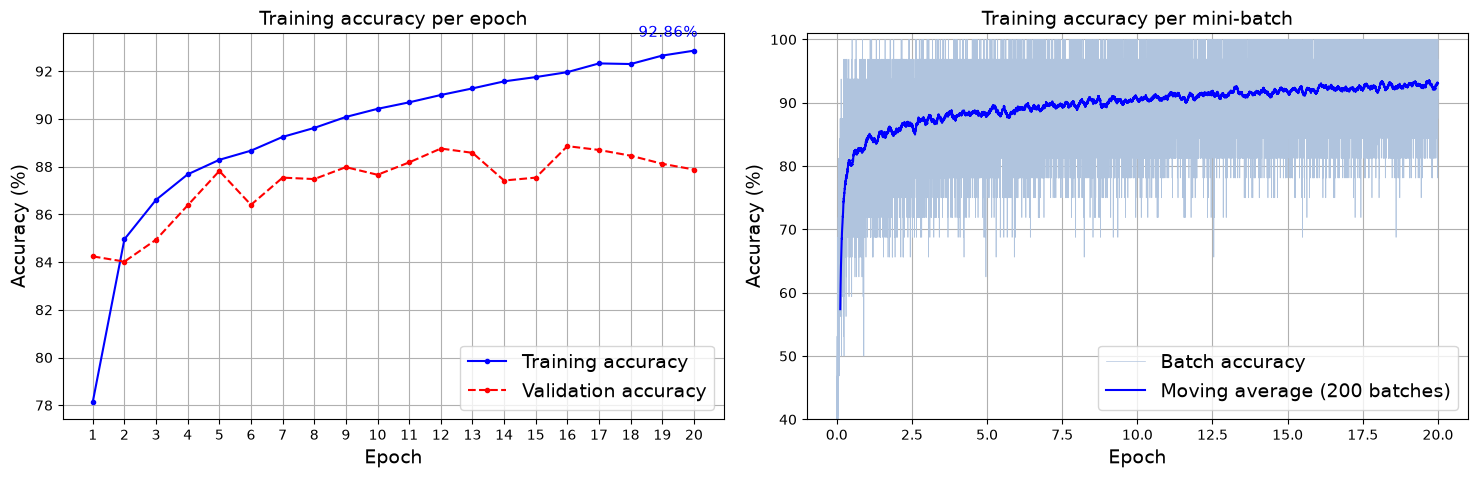

Final training accuracy:   92.86%
Final validation accuracy: 87.88%


In [7]:
# ===== Script 07 — 07_plot_training_accuracy.py =====
epochs = np.arange(1, n_epochs + 1)
train_acc = np.array(history["train_metrics"]) * 100
valid_acc = np.array(history["valid_metrics"]) * 100
batch_acc = np.array(history["batch_train_metrics"]) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs, train_acc, "b.-", label="Training accuracy")
ax1.plot(epochs, valid_acc, "r.--", label="Validation accuracy")
best = train_acc.argmax()
ax1.annotate(f"{train_acc[best]:.2f}%", (epochs[best], train_acc[best]),
             textcoords="offset points", xytext=(-40, 10), fontsize=11, color="b")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Training accuracy per epoch")
ax1.set_xticks(epochs)
ax1.grid(True)
ax1.legend(loc="lower right")

window = 200
steps = np.arange(1, len(batch_acc) + 1) / len(train_loader)
moving_avg = np.convolve(batch_acc, np.ones(window) / window, mode="valid")
ax2.plot(steps, batch_acc, color="lightsteelblue", linewidth=0.5,
         label="Batch accuracy")
ax2.plot(steps[window - 1:], moving_avg, "b-",
         label=f"Moving average ({window} batches)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training accuracy per mini-batch")
ax2.set_ylim(40, 101)
ax2.grid(True)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Final training accuracy:   {train_acc[-1]:.2f}%")
print(f"Final validation accuracy: {valid_acc[-1]:.2f}%")

## Script 08 — `08_evaluate_and_predict.py`: test accuracy and predictions

Test accuracy: 88.24%



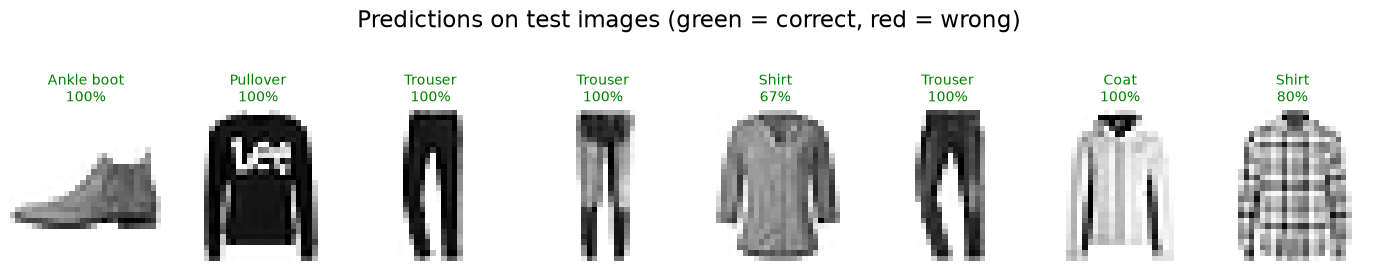

true: Ankle boot   predicted: Ankle boot   (100.0%)
true: Pullover     predicted: Pullover     (99.7%)
true: Trouser      predicted: Trouser      (100.0%)
true: Trouser      predicted: Trouser      (100.0%)
true: Shirt        predicted: Shirt        (67.3%)
true: Trouser      predicted: Trouser      (100.0%)
true: Coat         predicted: Coat         (100.0%)
true: Shirt        predicted: Shirt        (80.2%)


In [8]:
# ===== Script 08 — 08_evaluate_and_predict.py =====
test_acc = evaluate(model, test_loader, accuracy).item()
print(f"Test accuracy: {test_acc:.2%}\n")

model.eval()
X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new[:8].to(device), y_new[:8]
with torch.no_grad():
    y_proba = torch.softmax(model(X_new), dim=1).cpu()
confidence, y_pred = y_proba.max(dim=1)

plt.figure(figsize=(14, 3.2))
for i in range(len(X_new)):
    plt.subplot(1, len(X_new), i + 1)
    plt.imshow(X_new[i].cpu().squeeze(), cmap="binary")
    plt.axis("off")
    correct = y_pred[i] == y_new[i]
    plt.title(f"{class_names[y_pred[i]]}\n{confidence[i]:.0%}",
              fontsize=10, color="green" if correct else "red")
plt.suptitle("Predictions on test images (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

for i in range(len(X_new)):
    print(f"true: {class_names[y_new[i]]:<12} predicted: "
          f"{class_names[y_pred[i]]:<12} ({confidence[i]:.1%})")

## Script 09 — `09_save_model.py`: save, reload and verify the model

In [9]:
# ===== Script 09 — 09_save_model.py =====
torch.save(model.state_dict(), "problem3_fashion_mnist_model.pt")

loaded_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden1,
                               n_hidden2=n_hidden2, n_classes=10).to(device)
loaded_model.load_state_dict(torch.load("problem3_fashion_mnist_model.pt",
                                        weights_only=True))
loaded_model.eval()
with torch.no_grad():
    same = torch.allclose(model(X_new), loaded_model(X_new))
loaded_test_acc = evaluate(loaded_model, test_loader, accuracy).item()
print("Saved to problem3_fashion_mnist_model.pt")
print(f"Reloaded model gives identical outputs: {same}")
print(f"Reloaded model test accuracy: {loaded_test_acc:.2%}")

Saved to problem3_fashion_mnist_model.pt
Reloaded model gives identical outputs: True
Reloaded model test accuracy: 88.24%


## Script 10 — `10_self_test.py`: verify the notebook ran correctly

In [10]:
# ===== Script 10 — 10_self_test.py =====
assert len(train_data) == 55_000 and len(valid_data) == 5_000 and len(test_data) == 10_000
for key in ("train_losses", "train_metrics", "valid_metrics"):
    assert len(history[key]) == n_epochs, key
assert len(history["batch_train_metrics"]) == n_epochs * len(train_loader)
assert history["train_losses"][-1] < history["train_losses"][0], "loss did not decrease"
assert history["train_metrics"][-1] > history["train_metrics"][0], "accuracy did not improve"
assert test_acc > (0.80 if QUICK_RUN else 0.85), f"test accuracy too low: {test_acc:.2%}"
assert same and abs(loaded_test_acc - test_acc) < 1e-6
print("All checks passed.")

All checks passed.


## Summary of the Claude Code dialog (Problem 3)

1. **Request.** In a new session, I asked Claude Code in a single, longer prompt to do everything
   from Problems 1 and 2: build the Fashion MNIST PyTorch process incrementally as scripts based on the
   Chapter 10 template, add code that plots the training accuracy, organize the scripts as clearly
   labeled cells in executable order, wrap it all in one Jupyter notebook, and produce an HTML version.
2. **Clarifying questions.** Before creating anything, Claude Code confirmed its understanding and asked
   whether to reuse the earlier work or start fresh, whether to keep separate `.py` files, where to
   put the dialog summary, what to name the files, and whether to change the training settings.
3. **Answers.** Start fresh; output a single notebook (no separate script files) named *problem 3*;
   keep everything else the same (20 epochs, batch size 32, SGD with lr = 0.1, 300/100 hidden units,
   55,000/5,000/10,000 split).
4. **Build.** Claude Code set up the environment (PyTorch, TorchVision, TorchMetrics, Jupyter), wrote
   the ten scripts directly as labeled notebook cells, and added a self-test cell.
5. **Test and export.** It ran the notebook top to bottom with `jupyter nbconvert --execute`, checked
   that every cell passed, exported `problem3.html`, and committed both files to the GitHub repository.